In [ ]:
#################### Numerical & Physical Mixing in Ideal ROMS-Budgell Beaufort Jet ########################
# The purpose of this script is to plot time series of volume-averaged numerical and physical 
# mixing for salinity and temperature. Other processing for time series might be added in here, too,
# but all post-processed data will be save to netCDFs so the analysis does not need to be redone 
# to replot things. 
#
# Notes:
# - This script runs in xroms 
# - Other things that will maybe be added into here: energy analysis of eddy things, 
#   M2 and N2, ice volume/concentration/whatever is standard in papers
# - Choose an area that always has eddies, vertical slices constrained to top 200 m, 
# - This script heavily uses code from Dylan Schlichting 
##############################################################################################################

In [2]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
import xarray as xr
import xroms
from matplotlib import ticker
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

# The core of the analysis is done with xhistogram
from xhistogram.xarray import histogram

## Define Functions 
Make functions to help with processing the output

In [3]:
# Make a function to open the model output
def open_roms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_netcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [4]:
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [5]:
# Make a function to calculate useful derivatives and add them back into 
# the dataset
def add_derivatives(ds, grid, q='salt'):
    '''
Analysis of velocity gradient tensor and frontogenesis function
following Hetland et al. (2025) JPO
    '''
    qs = ds[q]
    
    #############################
    # Flow and property gradients at the ocean surface
    
    ds['dqdx'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'X'), grid)    # defined at rho-points
    ds['dqdy'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'Y'), grid)    # defined at rho-points
    
    ds['dudx'] = grid.derivative(ds.isel(s_rho=-1).u, 'X', boundary='extend')  # defined at rho-points
    ds['dvdy'] = grid.derivative(ds.isel(s_rho=-1).v, 'Y', boundary='extend')  # defined at rho-points
    ds['dvdx'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).v, 'X', boundary='extend'), grid)  # defined at rho-points
    ds['dudy'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).u, 'Y', boundary='extend'), grid)  # defined at rho-points
    
    ###########################
    # Invariant flow properties
    
    # Vorticity:  v_x - u_y
    ds['zeta'] = (ds.dvdx - ds.dudy)/ds.f
    ds['zeta'].name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    ds['delta'] = (ds.dudx + ds.dvdy)/ds.f
    ds['delta'].name = 'Normalized divergence'

    # Major axis of deformation
    ds['alpha'] = ( np.sqrt( (ds.dudx-ds.dvdy)**2 + (ds.dvdx+ds.dudy)**2 ) )/ds.f
    ds['alpha'].name = 'Normalized total strain'

    ##################################
    # Principle deformation components

    ds['lminor'] = 0.5 * (ds.delta - ds.alpha)
    ds['lminor'].name = 'lambda minor'

    ds['lmajor'] = 0.5 * (ds.delta + ds.alpha)
    ds['lmajor'].name = 'lambda major'
    
    #############################################
    # Along- and cross-frontal velocity gradients
    
    # angle is wrt x, so need to do arctan2(y, x)
    ds['phi_cf'] = np.arctan2(ds.dqdy, ds.dqdx)
    ds['phi_af'] = ds.phi_cf + np.pi/2.0

    ds['du_cf'] = ( ds.dudx*np.cos(ds.phi_cf)**2 + ds.dvdy*np.sin(ds.phi_cf)**2 
               + (ds.dudy + ds.dvdx)*np.sin(ds.phi_cf)*np.cos(ds.phi_cf) )/ds.f

    ds['du_af'] = ( ds.dudx*np.cos(ds.phi_af)**2 + ds.dvdy*np.sin(ds.phi_af)**2
              + (ds.dudy + ds.dvdx)*np.sin(ds.phi_af)*np.cos(ds.phi_af) )/ds.f
    
    ############################
    # The frontogenesis function
    
    # Dimensional frontogenesis function
    Dgradq_i = - ds.dudx*ds.dqdx - ds.dvdx*ds.dqdy
    Dgradq_j = - ds.dudy*ds.dqdx - ds.dvdy*ds.dqdy
    ds['Ddelq2'] = (ds.dqdx*Dgradq_i + ds.dqdy*Dgradq_j)
    ds['Ddelq2'].name = 'Frontogenesis function'

    # Density gradients squared
    ds['gradq2'] = ds.dqdx**2 + ds.dqdy**2
    ds['gradq2'].name = r'$(\nabla q)^2$'

    # Normalized frontogenesis function
    ds['nFGF'] = 0.5 * ds.Ddelq2 / (ds.gradq2 * ds.f)
    ds['nFGF'].name = r'Normalized Frontogenesis Function'
    
    return ds

## Post-Processing  
Load in and process the model output.

In [6]:
# Constant forcing (time series), ice, U3C4, K-eps
path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')

In [7]:
# Load in the output from above with xroms
ds, grid = open_mfroms(path)
add_derivatives(ds, grid)

<xarray.Dataset> Size: 6TB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 1002,
                         xi_rho: 402, eta_v: 1001, xi_u: 401, ocean_time: 1440)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 190GB dask.array<chunksize=(1, 41, 1001, 402), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 190GB dask.array<chunksize=(1, 41, 1001, 401), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 186GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1002, 401), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 185GB dask.array<chunksize=(1, 40, 1001, 402), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1001, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/168)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    phi_af              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_cf               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_af               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    Ddelq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    gradq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    nFGF                (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
Attributes: (12/29)
    file:              /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/rom...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -mcmodel=large -fallow-argument-mismat...
    tiling:            16x32
    history:           ROMS, Version 4.3, Monday - December 29, 2025 -  7:34:...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ANA_BPFLUX, ANA_BS...

In [8]:
print(ds.ocean_time[0:5].values)
print(ds.ocean_time[-5:-1].values)

[cftime.DatetimeProlepticGregorian(1, 1, 1, 1, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 3, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 5, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 7, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 9, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeProlepticGregorian(1, 4, 30, 15, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 17, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 19, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 21, 0, 0, 0, has_year_zero=True)]


## Mixing!  
Calculate mixing in the domain. First pick the region we want to do calculations over.

In [9]:
# Calculate distance in km
# to use for plotting 
# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds.x_rho[0,2].values - ds.x_rho[0,1].values
print('dx: ', dx)
dy = ds.y_rho[1,0].values - ds.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds.x_rho: ', ds.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds.y_rho: ', ds.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]

dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


In [10]:
print(len(ds.y_rho[:,0]))
print(len(y_rho))

1002
1002


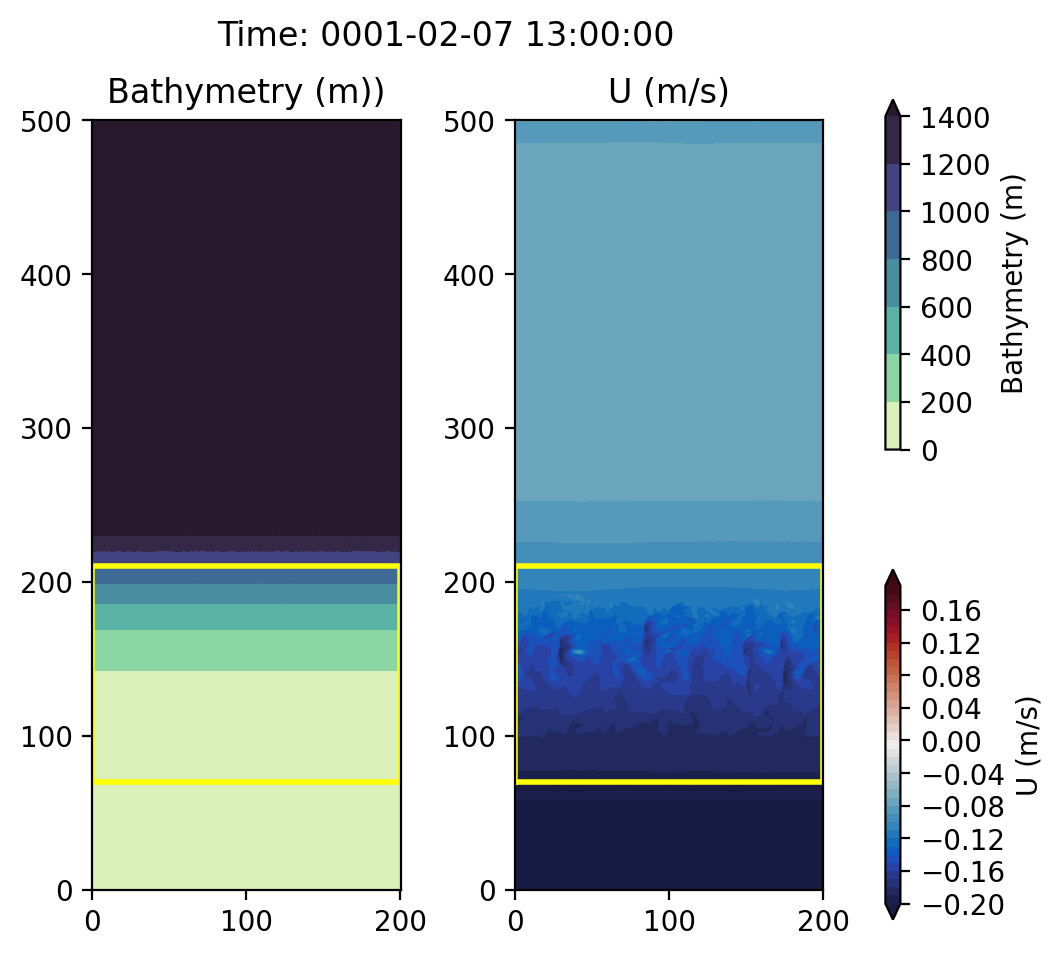

In [11]:
# Plot the domain to figure out where we want to take the 
# average in the horizontal 

# Set the time index
time_idx1 = 450

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)
lev_u = np.arange(-0.2, 0.2, 0.01)

# Make the figure 
fig, ax = plt.subplots(1, 2, figsize=(5,5), dpi=200)

# Plot bathymetry
cs1 = ax[0].contourf(x_rho/1000, y_rho/1000, ds.h, cmap=cmo.deep,
                     extend='max')
ax[0].set_title('Bathymetry (m))')
# Make a colorbar 
cbar_ax1 = fig.add_axes([0.94,0.55,0.015,0.35])
fig.colorbar(cs1,ax=ax,extend='both',
             label='Bathymetry (m)',
             pad=0.03, cax=cbar_ax1)

# Plot surface u
cs2 = ax[1].contourf(x_u/1000, y_u/1000, ds.u[time_idx1,-1,:,:], 
                     lev_u, cmap=cmo.balance, extend='both')
ax[1].set_title('U (m/s)')
# Make a colorbar 
cbar_ax2 = fig.add_axes([0.94,0.08,0.015,0.35])
fig.colorbar(cs2,ax=ax,extend='both',
             label='U (m/s)',
             pad=0.03, cax=cbar_ax2)

# Add other details to each subplot
for r in range(2):
    # Set aspect ratio
    ax[r].set_aspect(1.0)

# Add the time
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[0:19])

# Pick a region to analyze 
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
# Plot Box 1
ax[0].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)
ax[1].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)

fig.canvas.draw()
 

In [ ]:
# Find where these regions are in terms of xi and eta slicing 
# Becuase of periodic boundaries, we want the second to last 
# xi idx and to start at 1 and not 0
box_min_x_01_idx = ((box_min_x_01 * 1000)+dx)/dx
print('box_min_x_01_idx: ', box_min_x_01_idx)
box_max_x_01_idx = ((box_max_x_01 * 1000)-dx)/dx
print('box_max_x_01_idx: ', box_max_x_01_idx)
box_min_y_01_idx = (box_min_y_01 * 1000)/dy
print('box_min_y_01_idx: ', box_min_y_01_idx)
box_max_y_01_idx = (box_max_y_01 * 1000)/dy
print('box_max_y_01_idx: ', box_max_y_01_idx)

xi_slice = slice(int(box_min_x_01_idx), int(box_max_x_01_idx))
eta_slice = slice(int(box_min_y_01_idx), int(box_max_y_01_idx))

box_min_x_01_idx:  1.0
box_max_x_01_idx:  399.0
box_min_y_01_idx:  140.0
box_max_y_01_idx:  420.0


In [13]:
# Set the vertical max
# Note z_rho is negative in ROMS output so it will have 
# a negative sign in front of it when slicing
z_slice = 200 # meters

### Physical & Numerical Mixing  
I think we only want over the top 200 m but not fully sure how to do that with xroms yet soooooooooooo try some things...definitely linked to slicing? buttttt not sure howwww

In [ ]:
# How are we handling depth? Surface? but we want volume right so
# do up to 200 m depth?

In [ ]:
ds.ocean_time[0:5].values

In [ ]:
ds.z_rho[0,:,100,100].values

In [ ]:
# Get physical mixing from the output
# Salinity (2-hourly)
Akr_rho = grid.interp(ds.AKr, 'Z')
mphys = (Akr_rho*ds.dV).isel(eta_rho = eta_slice, xi_rho = xi_slice).where(ds.z_rho>-z_slice) .sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mphys.attrs = ''

# Temperature (2-hourly)
Akrt_rho = grid.interp(ds.AKrt, 'Z')
mphyt = (Akrt_rho*ds.dV).isel(eta_rho = eta_slice, xi_rho = xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mphyt.attrs = ''

In [ ]:
# Get numerical mixing from the output
# Numerical mixing (2-hourly)
mnum_salt_dv = (ds.dye_03*ds.dV).isel(eta_rho = eta_slice, xi_rho=xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mnum_temp_dv = (ds.dye_06*ds.dV).isel(eta_rho = eta_slice, xi_rho=xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()

### Save to NetCDF  
Save the post-processed data to a netCDF

In [ ]:
# Save all the 2-hourly data to the same netcdf

# Variables to save: mphys, mphyt, mnum_salt_dv, mnum_temp_dv

roms_phy_num_mix_salt_temp = xr.Dataset(
    data_vars=dict(
        mphys=(['ocean_time'], mphys.values),
        mphyt=(['ocean_time'], mphyt.values),
        mnum_salt_dv=(['ocean_time'], mnum_salt_dv.values),
        mnum_temp_dv=(['ocean_time'], mnum_temp_dv.values)
    ),
    coords=dict(
        ocean_time=('ocean_time', ds.ocean_time.values)
    ),
    attrs=dict(description='Time-series ROMS output including physical and numerical mixing of salinity and temperature from 2-hourly model output; uses /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')
)

# Add attributes to the 'temperature' data variable
roms_phy_num_mix_salt_temp['mphys'].attrs['long_name'] = 'Physical mixing of salinity at 2-hourly intervals'
roms_phy_num_mix_salt_temp['mphys'].attrs['units'] = '(g/kg)\u00b2(m\u00b3/s))'
roms_phy_num_mix_salt_temp['mphyt'].attrs['long_name'] = 'Physical mixing of temperature at 2-hourly intervals'
roms_phy_num_mix_salt_temp['mphyt'].attrs['units'] = '(C)\u00b2(m\u00b3/s))'

roms_phy_num_mix_salt_temp['mnum_salt_dv'].attrs['long_name'] = 'Numerical mixing of salinity at 2-hourly interval'
roms_phy_num_mix_salt_temp['mnum_salt_dv'].attrs['units'] = '(g/kg)\u00b2(m\u00b3/s))'
roms_phy_num_mix_salt_temp['mnum_temp_dv'].attrs['long_name'] = 'Numerical mixing of temperature at 2-hourly interval'
roms_phy_num_mix_salt_temp['mnum_temp_dv'].attrs['units'] = '(C)\u00b2(m\u00b3/s))'

# Save to a netcdf
# Run with ice
roms_phy_num_mix_salt_temp.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_keps_001.nc')
# Run without ice
#roms_phy_num_mix_salt_temp.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_no_ice_500m_const_forc_u3c4_keps_001.nc')


## Plot Mixing  
Plot timeseries of the mixing to compare 

In [ ]:
# If post-processed data is ready, load it in
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
#roms_phy_num_mix_ice = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_keps_001.nc')

# Run without sea ice, 500 m resolution, u3c4, k-epsilon
#roms_phy_num_mix_no_ice = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_no_ice_500m_const_forc_u3c4_keps_001.nc')


In [ ]:
# Re-assign the data from the post-processed data to work 
# with the plots below 
# Run with ice
mphys_ice = roms_phy_num_mix_ice.mphys
mphyt_ice = roms_phy_num_mix_ice.mphyt
mnum_salt_dv_ice = roms_phy_num_mix_ice.mnum_salt_dv
mnum_temp_dv_ice = roms_phy_num_mix_ice.mnum_temp_dv

# Run without ice 
mphys_no_ice = roms_phy_num_mix_no_ice.mphys
mphyt_no_ice = roms_phy_num_mix_no_ice.mphyt
mnum_salt_dv_no_ice = roms_phy_num_mix_no_ice.mnum_salt_dv
mnum_temp_dv_no_ice = roms_phy_num_mix_no_ice.mnum_temp_dv


In [ ]:
# Plot these comparisons 
# Compare phsyical and numerical mixing of salinity and temperature for the
# 2-hourly run
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
ax[0].plot(ds.ocean_time, mphys, color='deeppink', label=r'$\mathcal{M}_{phys,salt}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(ds.ocean_time, mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,salt}$')
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
ax[1].plot(ds.ocean_time, mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,temp}$')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(ds.ocean_time, mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,temp}$')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
ax[0].legend()
ax[0].set_xticklabels('')
ax[1].legend()
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_500m_const_forc_u3c4_keps_001.png')

In [ ]:
# Eventually come back and do a plot that compares
# the run with ice to the run without ice (and other 
# runs later/eventually, too)

In [ ]:
# Make a plot comparing run with ice to run witout ice
# Be sure to only compare the overlapping times 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# Ice
ax[0].plot(ds.ocean_time[:585], mphys_ice[:585], color='deeppink', label=r'$\mathcal{M}_{phys,salt,ice}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(ds.ocean_time[:585], mnum_salt_dv_ice[:585], color='turquoise', label=r'$\mathcal{M}_{num,salt,ice}$')
# No ice
ax[0].plot(ds.ocean_time[:585], mphys_no_ice[:585], color='deeppink', label=r'$\mathcal{M}_{phys,salt,no ice}$', linestyle='--')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(ds.ocean_time[:585], mnum_salt_dv_no_ice[:585], color='turquoise', label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# Ice
ax[1].plot(ds.ocean_time[:585], mphyt_ice[:585], color='palevioletred', label=r'$\mathcal{M}_{phys,temp,ice}$')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(ds.ocean_time[:585], mnum_temp_dv_ice[:585], color='lightseagreen', label=r'$\mathcal{M}_{num,temp,ice}$')
# No ice
ax[1].plot(ds.ocean_time[:585], mphyt_no_ice[:585], color='palevioletred', label=r'$\mathcal{M}_{phys,temp,no ice}$', linestyle='--')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(ds.ocean_time[:585], mnum_temp_dv_no_ice[:585], color='lightseagreen', label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# Label plot
ax[1].set_xlabel('Time')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
ax[0].legend()
ax[0].set_xticklabels('')
ax[1].legend()
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')